In [54]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
import mlflow
import mlflow.sklearn

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu,linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
#Training Data.
#Skip the header as it is not a number.
#Each row corresponds to a movie and displays its runtime, IMDB rating, IMDB number of votes,...
X = np.genfromtxt('../Data/Training_X.csv', delimiter=',', skip_header=1)  
m, n = X.shape
#Each row of y says if 2.5*movie_budget was greater than worldwide_gross. This is the metric we are using to 
#determine if a movie was successful.
y = np.genfromtxt('../Data/Training_Y.csv', delimiter=',', skip_header=1)

In [45]:
#Splitting data to have a part of it for testing and cross-validation
#I am saving 30% of the total data for that purpose.
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.3, random_state=1)

#Then split into test and cross-validation that 30%. Half goes to cv half to test.
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.50, random_state=1)

#Normalize the data so that features are on the same range.
#scaler = MinMaxScaler()
#scaler.fit(X_train)
#X_train_norm=scaler.transform(X_train)

#Transform test and cross-validation data as well
#X_cv_norm=scaler.transform(X_cv)
#X_test_norm=scaler.transform(X_test)

In [46]:
#Normalize the data so that features are on the same range.
#Tried also standard scaler.
scaler= StandardScaler()
scaler.fit(X_train)
X_train_norm=scaler.transform(X_train)

#Transform test and cross-validation data as well
X_cv_norm=scaler.transform(X_cv)
X_test_norm=scaler.transform(X_test)


In [47]:
#Multilayer perceptron to be trained on the data.
#Input size is the number of features of each example.
#, kernel_regularizer=regularizers.l2(0.01)
model = Sequential(                      
    [                                   
        tf.keras.Input(shape=(n,)),  
        Dense(40, activation='relu'),
        Dense(1,  activation='linear')
    ], name = "my_model"                                    
) 
#I made the last layer linear and apply the sigmoid manually.

#Define a loss function and use adaptative alpha (Adam) to perform gradient descent. 
#It is important to specify from_logits=True as the last layer is not a sigmoid. To make it numerically stable
#the sigmoid is in that way applied when computing the cost. 
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.001),
)

#I use early_stopping to allow a fast evaluation of any one model.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',      
    patience=5,              # epochs to wait before stopping
    restore_best_weights=True
)

history = model.fit(
    X_train_norm, y_train,
    validation_data=(X_cv_norm, y_cv),
    epochs=1000,
    callbacks=[early_stopping]
)
'''
model.fit(
    X_train_norm, y_train,
    validation_data=(X_cv_norm, y_cv),
    epochs=170
)
'''

Epoch 1/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step - loss: 0.6568 - val_loss: 0.6130
Epoch 2/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - loss: 0.6034 - val_loss: 0.5971
Epoch 3/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - loss: 0.5907 - val_loss: 0.5925
Epoch 4/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 423us/step - loss: 0.5840 - val_loss: 0.5904
Epoch 5/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - loss: 0.5791 - val_loss: 0.5888
Epoch 6/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - loss: 0.5751 - val_loss: 0.5864
Epoch 7/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - loss: 0.5714 - val_loss: 0.5885
Epoch 8/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - loss: 0.5680 - val_loss: 0.5864
Epoch 9/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 417us/step - loss: 0.5654 - val_loss: 0.5849
Epoch 10/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - loss: 0.5625 - val_loss: 0.5862
Epoch 11/1000
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step - loss: 0.5603 - val_loss: 0.5822
Epoch 12

'\nmodel.fit(\n    X_train_norm, y_train,\n    validation_data=(X_cv_norm, y_cv),\n    epochs=170\n)\n'

In [48]:
val_loss = model.evaluate(X_cv_norm, y_cv)
print("Validation loss:", val_loss)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - loss: 0.5815
Validation loss: 0.5815289616584778


In [49]:
#Routine to make predictions for X_input
def model_predict(X_input):
    '''
     X_input    : (ndarray )  Array of features to predict
     returns yhat a numpy array of 0/1 values corresponding to predictions.
    '''    
    #Making predictions.
    prediction = model.predict(X_input)
    #Applying the sigmoid at the end manually.
    probs = tf.nn.sigmoid(prediction).numpy()
    
    #Convert to 0/1 predictions
    yhat=np.zeros(len(probs))
    for i in range(len(probs)):    
        #Threshold to convert the predictions into TRUE/FALSE outputs.
        if probs[i] >= 0.5:
            yhat[i] = 1
        else:
            yhat[i] = 0
    return yhat
    

In [50]:
# Classification Error.
def eval_cat_err(y, yhat):
    """ 
      y    : (ndarray  Shape (m,) or (m,1))  target value of each example
      yhat : (ndarray  Shape (m,) or (m,1))  predicted value of each example           
    """
    m = len(y)
    incorrect = 0
    for i in range(m):
     
        if(y[i]!=yhat[i]):
            incorrect+=1
            
    cerr=incorrect/m
     
    
    return(cerr)

#Error on training set and cross-validation set.
training_cerr = eval_cat_err(y_train, model_predict(X_train_norm))
cv_cerr = eval_cat_err(y_cv, model_predict(X_cv_norm))


print("Training Error")
print(training_cerr)
print("Cross-validation Error")
print(cv_cerr)
print("With weights")
print(model.get_weights())

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 267us/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step
Training Error
0.2713019768234492
Cross-validation Error
0.3138918345705196
With weights
[array([[-0.05287376, -0.16998444,  0.21088472, ...,  0.24471   ,
        -0.19452098, -0.07916787],
       [ 0.10290645, -0.25728858,  0.11263129, ...,  0.00360654,
        -0.15091407,  0.23253621],
       [-0.17991036,  0.22613485, -0.02052885, ..., -0.11420751,
        -0.02454804, -0.20160444],
       ...,
       [ 0.26845136, -0.24080786, -0.2480818 , ...,  0.11292783,
         0.0199862 , -0.19510867],
       [-0.19039959,  0.02019342,  0.16446921, ...,  0.00395682,
         0.2567375 ,  0.22190483],
       [-0.02413376,  0.10461179,  0.0325627 , ...,  0.13842295,
         0.33886498,  0.03056468]], shape=(31, 40), dtype=float32), array([-0.11536758,  0.22003986, -0.06888583,  0.18980639,  0.10229723,
        0.0606472 , -0.20015094, -0.07323094, -0.09268842, -0.09189922,
       -0.0305742 ,  0.01519314, -0.1

In [51]:
#Error for reporting model accuracy
accuracy = eval_cat_err(y_test, model_predict(X_test_norm))
print(accuracy)

#Saving the experiments to keep a record and then easily determine the best
mlflow.set_experiment("BOff_Success_Prediction")

with mlflow.start_run():
    mlflow.log_metric("val_loss", val_loss)
    mlflow.log_metric("Training Error", training_cerr)
    mlflow.log_metric("Cross-validation Error", cv_cerr)
    mlflow.tensorflow.log_model(
        model,
        name="model"
    )

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step


2026/08/07 21:57:21 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


0.298728813559322


In [30]:
'''from mlflow import MlflowClient

client = MlflowClient()

runs = client.search_runs(
    experiment_ids=["1"],
    order_by=["metrics.val_loss ASC"]
)

for run in runs:
    print(run.info.run_id)
    print(run.data.metrics)
    print(run.data.params)
    model = mlflow.tensorflow.load_model(
    f"runs:/{run.info.run_id}/model"
    )
    model.summary()
    '''

'from mlflow import MlflowClient\n\nclient = MlflowClient()\n\nruns = client.search_runs(\n    experiment_ids=["1"],\n    order_by=["metrics.val_loss ASC"]\n)\n\nfor run in runs:\n    print(run.info.run_id)\n    print(run.data.metrics)\n    print(run.data.params)\n    model = mlflow.tensorflow.load_model(\n    f"runs:/{run.info.run_id}/model"\n    )\n    model.summary()\n    '

In [52]:
"Serialize the model"
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [53]:
#Now we test data from 2023
#Training Data.
#Skip the header as it is not a number.
#Each row corresponds to a movie and displays its runtime, IMDB rating, IMDB number of votes,...
X_1 = np.genfromtxt('../Data/Hypothesis_X.csv', delimiter=',', skip_header=1)  
m_1, n_1 = X_1.shape
#Each row of y says if 2.5*movie_budget was greater than worldwide_gross. This is the metric we are using to 
#determine if a movie was successful.
y_1 = np.genfromtxt('../Data/Hypothesis_Y.csv', delimiter=',', skip_header=1)

#We have to scale before predicting
X_1_test=scaler.transform(X_1)

data2023_cerr = eval_cat_err(y_1, model_predict(X_1_test))


print("2023 Error")
print(data2023_cerr)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2023 Error
0.3287671232876712


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
True positives 0.12643678160919541


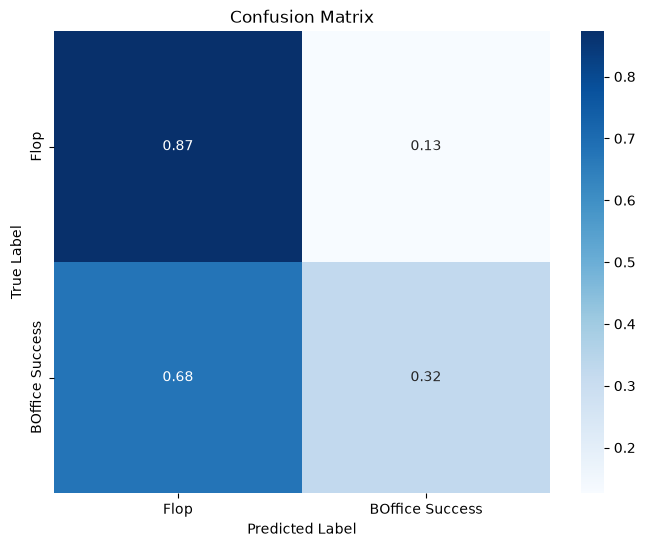

In [73]:
#Finally, I generate a confusion matrix for 2023 data.
y_pred_probs = model.predict(X_1_test)
y_pred = (y_pred_probs >= 0.5).astype(int).ravel()

true_positives=[i for i in range(len(y_1)) if y_pred[i]==1 and y_1[i]==0 ]
positives=[i for i in range(len(y_1)) if y_1[i]==0 ]

print(f"True positives {len(true_positives)/len(positives)}")

cm = confusion_matrix(y_1, y_pred, normalize="true")

plt.figure(figsize=(8, 6))

class_names=['Flop', 'BOffice Success']

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("../plots/confusion_matrix_2013.png", dpi=300, bbox_inches="tight")
plt.show()